In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load both CSV files and stack them into one combined table
df1 = pd.read_csv("../data/customer_data.csv")
df2 = pd.read_csv("../data/customer_data2.csv")
data = pd.concat([df1, df2], ignore_index=True)

print("Combined shape:", data.shape)
data.head()

Combined shape: (505207, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [17]:
# Check data types and look for missing values
print(data.info())
display(data.describe(include="all").transpose())
print("\nMissing values per column:")
print(data.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  str    
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  str    
 8   Contract Length    505206 non-null  str    
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), str(3)
memory usage: 46.3 MB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,505206.0,NaN,NaN,NaN,200779.451782,137241.343095,1.0,63827.25,193039.5,321645.75,449999.0
Age,505206.0,NaN,NaN,NaN,39.704172,12.670577,18.0,29.0,40.0,49.0,65.0
Gender,505206,2,Male,280273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure,505206.0,NaN,NaN,NaN,31.350435,17.237482,1.0,16.0,32.0,46.0,60.0
Usage Frequency,505206.0,NaN,NaN,NaN,15.714825,8.619323,1.0,8.0,16.0,23.0,30.0
Support Calls,505206.0,NaN,NaN,NaN,3.833317,3.133603,0.0,1.0,3.0,6.0,10.0
Payment Delay,505206.0,NaN,NaN,NaN,13.496843,8.451187,0.0,6.0,13.0,20.0,30.0
Subscription Type,505206,3,Standard,170630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Contract Length,505206,3,Annual,198608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Spend,505206.0,NaN,NaN,NaN,620.072766,245.319256,100.0,446.0,648.9,824.0,1000.0



Missing values per column:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64


In [18]:
# Drop the one row with a missing Churn value - we don't know its real answer
data = data.dropna(subset=["Churn"])

print("Rows after dropping the missing-Churn row:", len(data))

# Check the churn balance
churn_counts = data["Churn"].value_counts()
churn_percent = data["Churn"].value_counts(normalize=True) * 100

print("\nChurn counts:")
print(churn_counts)
print("\nChurn percentage:")
print(churn_percent.round(1))

Rows after dropping the missing-Churn row: 505206

Churn counts:
Churn
1.0    280492
0.0    224714
Name: count, dtype: int64

Churn percentage:
Churn
1.0    55.5
0.0    44.5
Name: proportion, dtype: float64


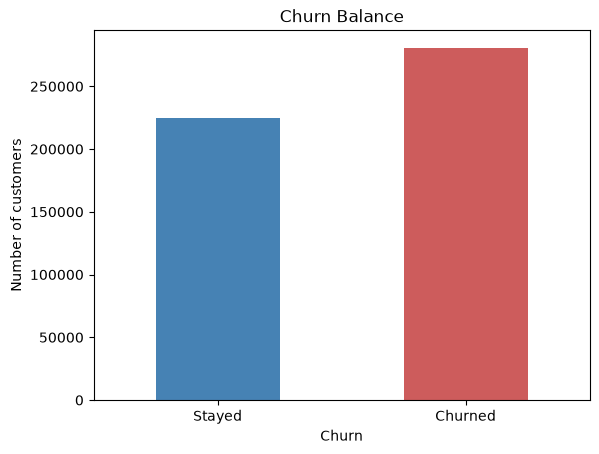

In [19]:
# # Visualize the churn balance as a bar chart
# churn_counts.plot(kind="bar", color=["steelblue", "indianred"])
# plt.xticks([0, 1], ["Stayed", "Churned"], rotation=0)
# plt.ylabel("Number of customers")
# plt.title("Churn Balance")
# plt.show()
# Visualize the churn balance as a bar chart
# sort_index() ensures the bars appear in order 0, 1 -
# matching our labels below. Without this, pandas sorts by
# count instead, which can silently mislabel the bars.
churn_counts.sort_index().plot(kind="bar", color=["steelblue", "indianred"])
plt.xticks([0, 1], ["Stayed", "Churned"], rotation=0)
plt.ylabel("Number of customers")
plt.title("Churn Balance")
plt.show()

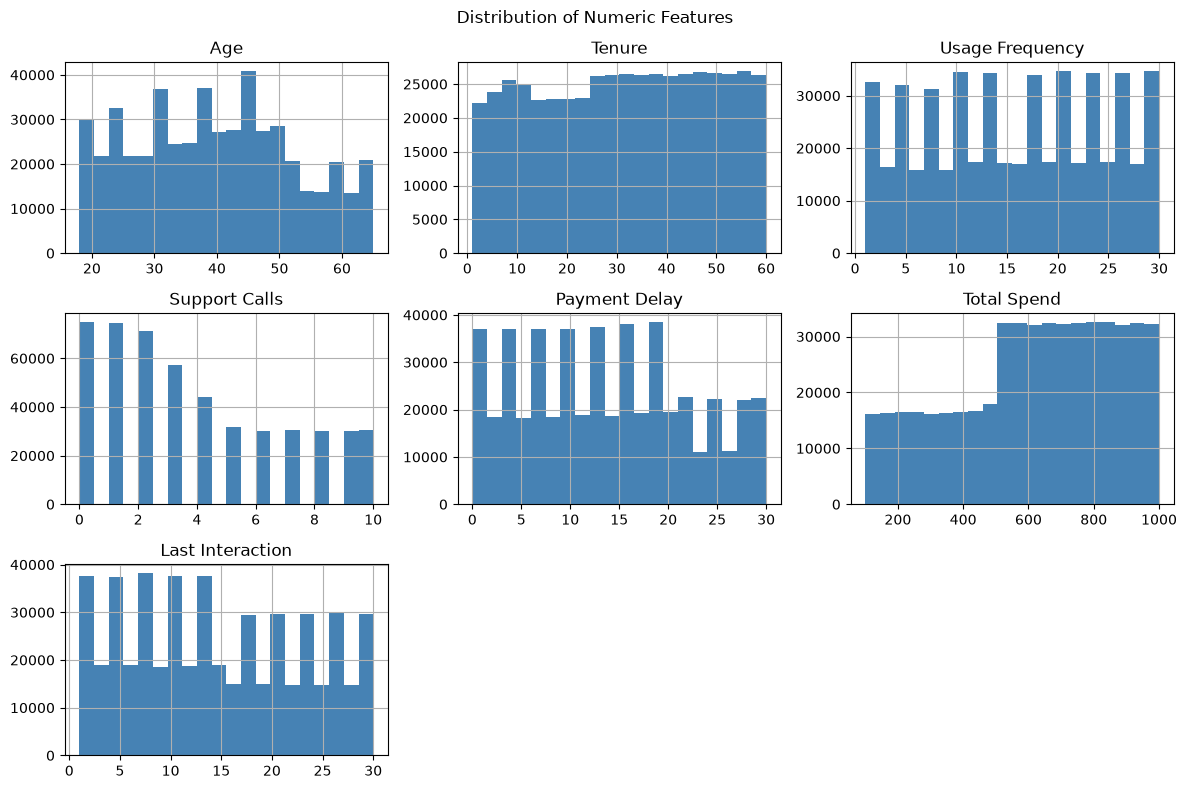

In [20]:
numeric_cols = ["Age", "Tenure", "Usage Frequency", "Support Calls",
                "Payment Delay", "Total Spend", "Last Interaction"]

data[numeric_cols].hist(figsize=(12, 8), bins=20, color="steelblue")
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

In [21]:
# Compare the average value of each numeric feature,
# split by whether the customer churned or not
comparison = data.groupby("Churn")[numeric_cols].mean()
print(comparison.round(1))

        Age  Tenure  Usage Frequency  Support Calls  Payment Delay  \
Churn                                                                
0.0    37.0    31.8             16.2            2.0           10.4   
1.0    41.9    31.0             15.3            5.3           16.0   

       Total Spend  Last Interaction  
Churn                                 
0.0          721.4              13.4  
1.0          538.9              15.6  


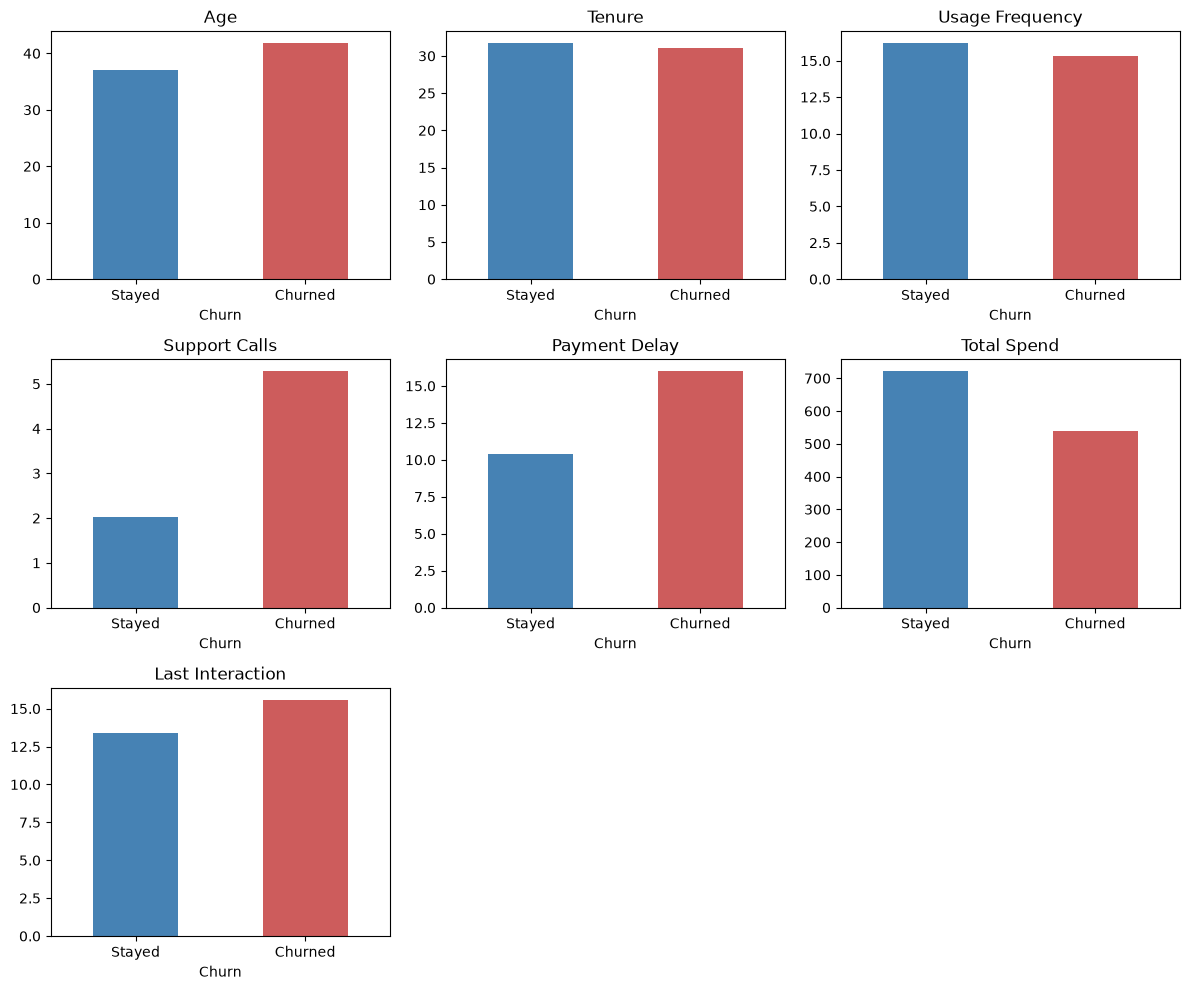

In [22]:
# Problem version of the bar chart - the bars are stacked, which is not what we want
# comparison.T.plot(kind="bar", figsize=(10, 5))
# plt.ylabel("Average value")
# plt.title("Average Feature Values: Stayed vs Churned")
# plt.legend(["Stayed", "Churned"])
# plt.xticks(rotation=45)
# plt.show()
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()  # turn the 3x3 grid into a simple list of 9 slots

for i, col in enumerate(numeric_cols):
    comparison[col].plot(kind="bar", ax=axes[i], color=["steelblue", "indianred"])
    axes[i].set_xticklabels(["Stayed", "Churned"], rotation=0)
    axes[i].set_title(col)

# Hide the 2 unused empty slots (we have 7 features, but a 3x3 grid has 9 slots)
axes[7].axis("off")
axes[8].axis("off")

plt.tight_layout()
plt.show()

In [23]:
category_cols = ["Gender", "Subscription Type", "Contract Length"]

for col in category_cols:
    churn_rate = data.groupby(col)["Churn"].mean() * 100
    print(f"\nChurn rate by {col}:")
    print(churn_rate.round(1))


Churn rate by Gender:
Gender
Female    64.9
Male      48.0
Name: Churn, dtype: float64

Churn rate by Subscription Type:
Subscription Type
Basic       56.9
Premium     54.8
Standard    55.0
Name: Churn, dtype: float64

Churn rate by Contract Length:
Contract Length
Annual       46.1
Monthly      90.2
Quarterly    45.8
Name: Churn, dtype: float64


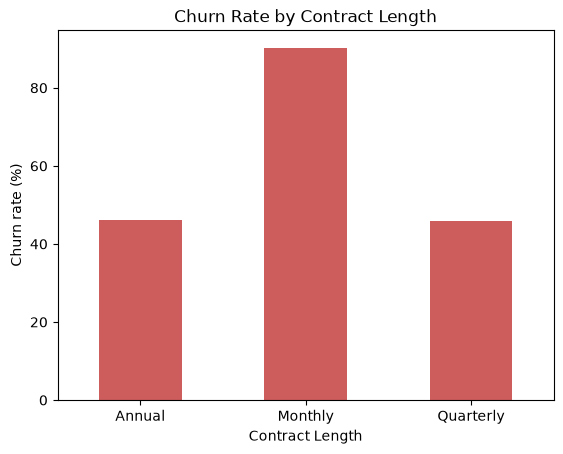

In [24]:
contract_churn = data.groupby("Contract Length")["Churn"].mean() * 100

contract_churn.plot(kind="bar", color="indianred")
plt.ylabel("Churn rate (%)")
plt.title("Churn Rate by Contract Length")
plt.xticks(rotation=0)
plt.show()

In [25]:
# Correlation needs numbers, so we convert the text columns into
# numeric codes just for this chart (we are NOT changing the
# original 'data' table - this is a separate copy).
data_encoded = data.copy()
for col in category_cols:
    data_encoded[col] = data_encoded[col].astype("category").cat.codes

correlation_cols = numeric_cols + category_cols + ["Churn"]
correlation = data_encoded[correlation_cols].corr()

print(correlation["Churn"].sort_values(ascending=False).round(2))

Churn                1.00
Support Calls        0.52
Payment Delay        0.33
Age                  0.19
Last Interaction     0.13
Contract Length     -0.00
Subscription Type   -0.02
Tenure              -0.02
Usage Frequency     -0.05
Gender              -0.17
Total Spend         -0.37
Name: Churn, dtype: float64


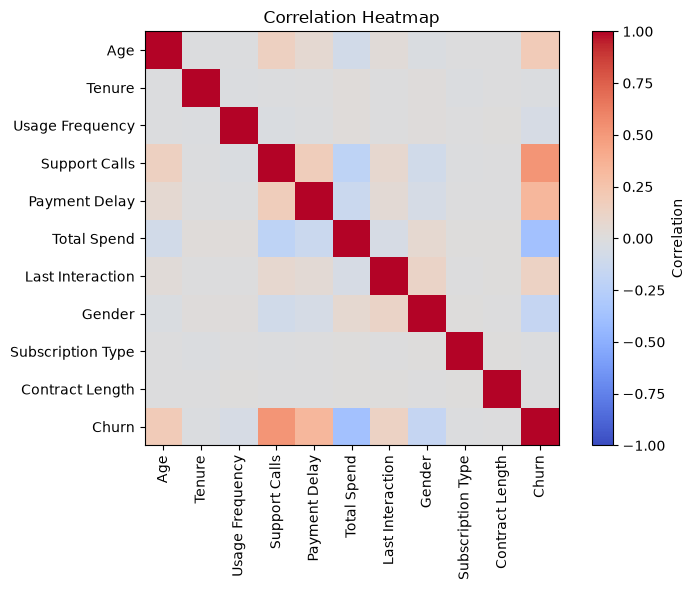

In [26]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_cols)), correlation_cols, rotation=90)
plt.yticks(range(len(correlation_cols)), correlation_cols)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()